# Week 4: Introduction to Machine Learning — Simplified Examples

## Learning from data, testing fairly, and deciding whether a model is useful

This notebook keeps the same machine-learning workflow and learning goals, but uses **simple student examples** instead of motor-monitoring examples.

We will mainly ask questions such as:
- Will a student pass or fail?
- What exam score might a student get?
- Can we group students by study behaviour?

The datasets are intentionally small and easy to read so that you can focus on understanding **what machine learning is doing**, not on complicated data.

### By the end of this notebook, you should be able to

1. Explain the difference between ordinary programming and machine learning.
2. Identify rows, features, targets, `X`, and `y`.
3. Distinguish classification, regression, and clustering.
4. Inspect a dataset before modelling.
5. Explain missing values, encoding, and scaling.
6. Create a train/test split.
7. Build a simple baseline.
8. Train and evaluate classification models.
9. Explain accuracy, precision, recall, F1, and the confusion matrix.
10. Calculate common regression metrics.
11. Recognize underfitting, reasonable fit, and overfitting.
12. Detect common forms of data leakage.
13. Use validation and cross-validation.
14. Inspect model errors before deciding whether a model is useful.

### How to use this notebook

For each section:

1. Read the explanation.
2. Predict what you think the code will do.
3. Run the cell.
4. Inspect the output.
5. Explain the result in your own words.

The goal is not to memorize scikit-learn commands. The goal is to understand the full machine learning workflow.


## 0. The complete machine learning workflow

A useful mental model is:

**Problem -> Prediction unit -> Data audit -> Split -> Preprocess -> Baseline -> Train -> Evaluate -> Inspect errors -> Decide**

The model is only one part of the system.

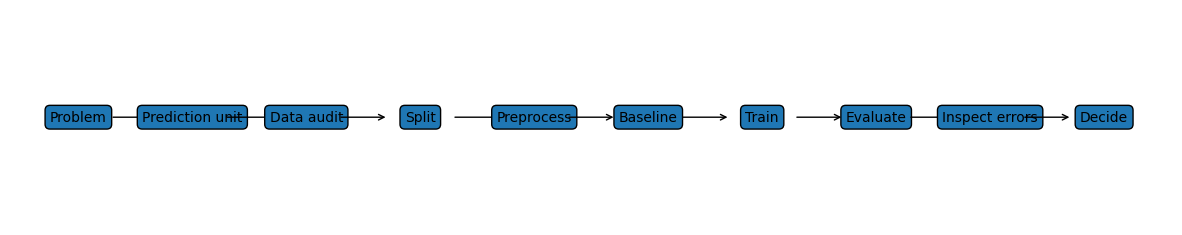

In [1]:
import matplotlib.pyplot as plt

steps = [
    "Problem", "Prediction unit", "Data audit", "Split", "Preprocess",
    "Baseline", "Train", "Evaluate", "Inspect errors", "Decide"
]

fig, ax = plt.subplots(figsize=(15, 2.8))
ax.axis("off")

for i, step in enumerate(steps):
    x = i
    ax.text(
        x, 0.5, step,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.35")
    )
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x + 0.72, 0.5),
            xytext=(x + 0.28, 0.5),
            arrowprops=dict(arrowstyle="->")
        )

ax.set_xlim(-0.6, len(steps) - 0.4)
ax.set_ylim(0, 1)
plt.show()

# Part A: What machine learning actually does

## 1. Ordinary programming: we write the rules

In ordinary programming, the programmer explicitly writes the decision rule.

Run the example below.

In [2]:
temperature = 87

if temperature > 80:
    print("Fan ON")
else:
    print("Fan OFF")


Fan ON


### Think

Who created the rule `temperature > 80`?

The programmer did.

This approach works well when rules are clear, stable, and manageable.

Machine learning becomes useful when the rules are difficult to write manually, but we have examples from which a system can learn patterns.

## 2. A tiny machine learning example

Suppose we have a few students. For each student, we know how many hours they studied, their attendance, and whether they passed.

Instead of writing a rule ourselves such as `study_hours >= 4`, we can give the examples to a model and ask it to learn a pattern.


In [3]:
import numpy as np
import pandas as pd

tiny_student_data = pd.DataFrame({
    "study_hours": [1, 2, 2.5, 3, 4, 5, 6, 7],
    "attendance": [55, 60, 65, 70, 75, 80, 85, 90],
    "passed": [0, 0, 0, 0, 1, 1, 1, 1]
})

tiny_student_data


,study_hours,attendance,passed
0,1.0,55,0
1,2.0,60,0
2,2.5,65,0
3,3.0,70,0
4,4.0,75,1
5,5.0,80,1
6,6.0,85,1
7,7.0,90,1


In [4]:
tiny_student_data["study_hours"].mean()

np.float64(3.8125)

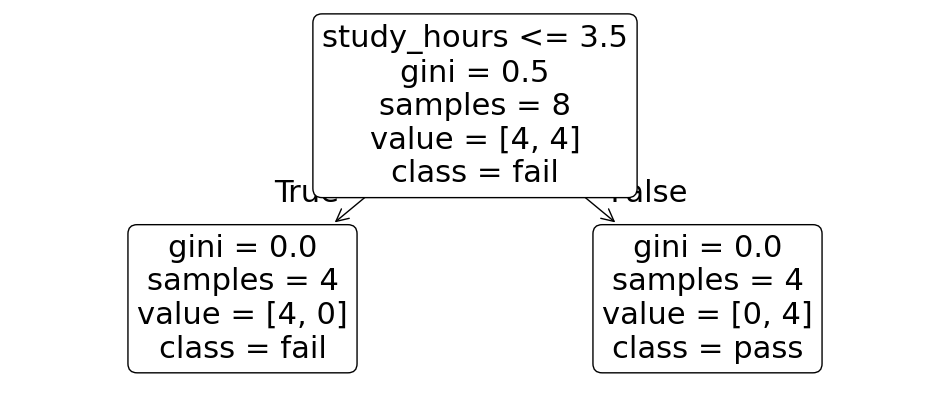

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

X_tiny = tiny_student_data[["study_hours", "attendance"]]
y_tiny = tiny_student_data["passed"]

tiny_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tiny_tree.fit(X_tiny, y_tiny)

plt.figure(figsize=(12, 5))

plot_tree(
    tiny_tree,
    feature_names=X_tiny.columns,
    class_names=["fail", "pass"],
    filled=False,
    rounded=True
)

plt.show()


### What happened?

The model looked at examples of students who passed and failed.

It searched for a simple question that separates the two groups, such as:

> **Is study time less than or equal to a certain number of hours?**

The model learned the rule from the examples instead of us writing the complete rule ourselves.


## 3. The real goal is generalisation

A useful model should work on **new students it has not seen before**.

If a model only memorises the examples we give it, it has not really learned a useful pattern.

This idea — working well on new examples — is called **generalisation**.


# Part B: Understanding the dataset

## 4. Create our main student dataset

We will use a small student-performance dataset throughout much of the notebook.

Our goal is simple:

> **Predict whether a student will pass or fail.**

Each row represents one student.

The features are:
- `study_hours`: hours studied per week
- `attendance`: attendance percentage
- `assignments_completed`: number of assignments completed

The target is:
- `passed`: `0` = fail, `1` = pass


In [6]:
rng = np.random.default_rng(42)

student_df = pd.DataFrame({
    "study_hours": [1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5,
                    5, 6, 6, 6, 7, 7, 7, 8, 8, 9, 9, 10],
    "attendance": [55, 60, 62, 65, 68, 70, 72, 70, 74, 78, 75, 80,
                   82, 80, 84, 86, 85, 88, 90, 87, 92, 94, 96, 98],
    "assignments_completed": [2, 3, 3, 4, 4, 5, 6, 5, 6, 7, 6, 7,
                              8, 7, 8, 9, 8, 9, 10, 8, 10, 9, 10, 10],
    "passed": [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
               1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
})

student_df


,study_hours,attendance,assignments_completed,passed
0,1,55,2,0
1,1,60,3,0
2,2,62,3,0
3,2,65,4,0
4,3,68,4,0
5,3,70,5,0
6,3,72,6,1
7,4,70,5,0
8,4,74,6,1
9,4,78,7,1


In [7]:
print("Shape:", student_df.shape)
print()
print("Class counts:")
print(student_df["passed"].value_counts().sort_index())


Shape: (24, 4)

Class counts:
passed
0     8
1    16
Name: count, dtype: int64


## 5. Rows, features, target, X, and y

A dataset is recorded experience.

- A **row** is one example.
- A **feature** is information the model is allowed to use.
- A **target** is the answer we want the model to predict in supervised learning.

The standard notation is:

- `X` = features
- `y` = target

In [8]:
X = student_df.drop(columns="passed")
y = student_df["passed"]

print("X contains the features:")
display(X.head())

print("\ny contains the target:")
display(y.head())


X contains the features:


,study_hours,attendance,assignments_completed
0,1,55,2
1,1,60,3
2,2,62,3
3,2,65,4
4,3,68,4



y contains the target:


0    0
1    0
2    0
3    0
4    0
Name: passed, dtype: int64

When you later see:

```python
model.fit(X_train, y_train)
```

read it as:

> Learn a relationship between the training features and their known answers.

# Part C: Classification, regression, and clustering

## 6. Classification

Classification predicts a **category**.

In this notebook, our classification question is:

> **Will the student pass or fail?**

Examples:
- spam or not spam
- pass or fail
- sick or healthy
- fraud or not fraud

Our target has two categories:

`0 = fail`

`1 = pass`


## 7. Regression

Regression predicts a **continuous number**.

In our simple example, we will predict:

> **A student's exam score from the number of hours they studied.**

Examples:
- exam score
- house price
- electricity demand
- sales amount


In [9]:
from sklearn.linear_model import LinearRegression

study_hours = np.arange(1, 11)
exam_scores = np.array([35, 42, 48, 55, 61, 68, 72, 80, 86, 92])

reg_demo = pd.DataFrame({
    "study_hours": study_hours,
    "exam_score": exam_scores
})

X_reg = reg_demo[["study_hours"]]
y_reg = reg_demo["exam_score"]

reg_model = LinearRegression()
reg_model.fit(X_reg, y_reg)

reg_predictions = reg_model.predict(X_reg)

print("Predicted score for 6 study hours:",
      round(reg_model.predict([[6]])[0], 1))

display(reg_demo)


Predicted score for 6 study hours: 67.0


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,study_hours,exam_score
0,1,35
1,2,42
2,3,48
3,4,55
4,5,61
5,6,68
6,7,72
7,8,80
8,9,86
9,10,92


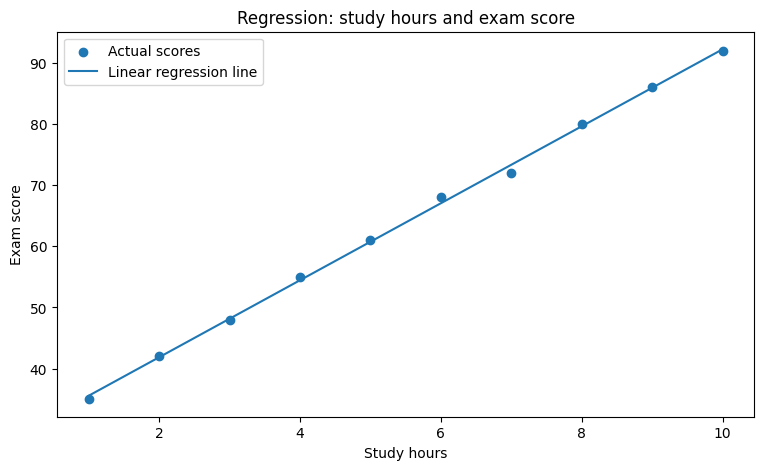

In [10]:
plt.figure(figsize=(9, 5))
plt.scatter(reg_demo["study_hours"], reg_demo["exam_score"], label="Actual scores")
plt.plot(reg_demo["study_hours"], reg_predictions, label="Linear regression line")
plt.xlabel("Study hours")
plt.ylabel("Exam score")
plt.title("Regression: study hours and exam score")
plt.legend()
plt.show()


## 8. Clustering

Clustering is an **unsupervised learning** task.

There is no target column. The model tries to find groups of similar observations.

For example, we can group students using:
- study hours
- exam score

The algorithm might discover a group of students who study less and score lower, and another group who study more and score higher.


,study_hours,exam_score,group
0,2.682830,39.800079,0
1,2.950271,49.702824,0
2,1.329379,38.489102,0
3,2.576704,43.418787,0
4,2.489919,40.734780,0


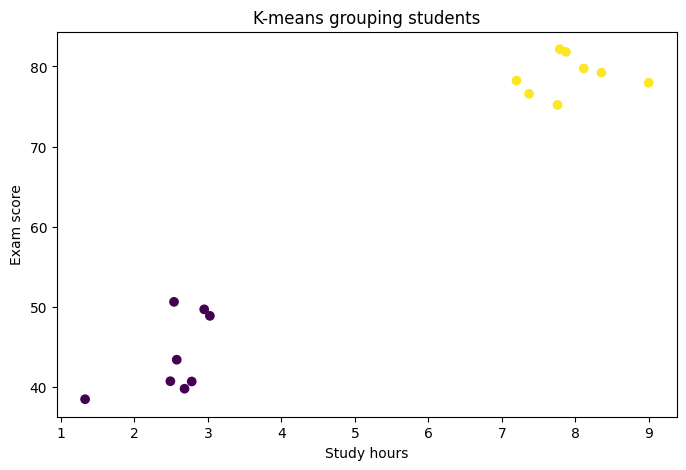

In [11]:
from sklearn.cluster import KMeans

cluster_a = rng.normal(
    loc=[2.5, 45],
    scale=[0.6, 5],
    size=(8, 2)
)

cluster_b = rng.normal(
    loc=[7.5, 80],
    scale=[0.7, 5],
    size=(8, 2)
)

cluster_data = np.vstack([cluster_a, cluster_b])

cluster_df = pd.DataFrame(
    cluster_data,
    columns=["study_hours", "exam_score"]
)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_df["group"] = kmeans.fit_predict(
    cluster_df[["study_hours", "exam_score"]]
)

display(cluster_df.head())

plt.figure(figsize=(8, 5))
plt.scatter(
    cluster_df["study_hours"],
    cluster_df["exam_score"],
    c=cluster_df["group"]
)
plt.xlabel("Study hours")
plt.ylabel("Exam score")
plt.title("K-means grouping students")
plt.show()


### Quick check

Decide the learning type before revealing the answers.

1. Predict crop disease category
2. Predict next-month electricity demand
3. Group customers with similar behaviour
4. Predict whether a login is malicious
5. Predict travel time in minutes
6. Discover operating modes in sensor data

In [12]:
answers = {
    1: "Classification",
    2: "Regression",
    3: "Clustering",
    4: "Classification",
    5: "Regression",
    6: "Clustering"
}

for number, answer in answers.items():
    print(f"{number}. {answer}")

1. Classification
2. Regression
3. Clustering
4. Classification
5. Regression
6. Clustering


# Part D: Data quality before modelling

## 9. A dataset is not ready just because pandas can read it

Real datasets can contain:
- missing values
- duplicates
- impossible values
- inconsistent text
- incorrect data types

We will use a small messy student dataset to see these problems.


In [13]:
dirty_df = pd.DataFrame({
    "student_id": ["S01", "S02", "S03", "S03", "S04", "S05"],
    "study_hours": [3, -2, 5, 5, "four", 7],
    "attendance": [70, 65, np.nan, np.nan, 80, 95],
    "assignments_completed": [4, 3, 7, 7, "?", 10],
    "passed": [0, 0, 1, 1, 1, 1]
})

dirty_df


,student_id,study_hours,attendance,assignments_completed,passed
0,S01,3,70.0,4,0
1,S02,-2,65.0,3,0
2,S03,5,NaN,7,1
3,S03,5,NaN,7,1
4,S04,four,80.0,?,1
5,S05,7,95.0,10,1


In [14]:
print("Data types:")
print(dirty_df.dtypes)

print("\nMissing values:")
print(dirty_df.isna().sum())

print("\nDuplicate rows:")
print(dirty_df.duplicated().sum())

Data types:
student_id                object
study_hours               object
attendance               float64
assignments_completed     object
passed                     int64
dtype: object

Missing values:
student_id               0
study_hours              0
attendance               2
assignments_completed    0
passed                   0
dtype: int64

Duplicate rows:
1


### Six useful data quality checks

1. **Completeness:** Are required values present?
2. **Validity:** Do values obey domain rules?
3. **Consistency:** Is one concept represented in the same way?
4. **Uniqueness:** Are duplicate records intentional?
5. **Timeliness:** Does the data match the prediction period?
6. **Representativeness:** Does the data resemble the environment where the model will be used?

Cleaning is not a ritual. Every cleaning choice changes the evidence.

## 10. Missing data

A missing value is not always just an empty cell.

For a sensor, a missing reading could mean:

- sensor failure
- lost network connection
- device was switched off
- logging software failed

Sometimes the fact that a value is missing can itself be informative.

In [15]:
missing_demo = pd.DataFrame({
    "study_hours": [2, 4, np.nan, 6, 8],
    "attendance": [60, np.nan, 75, 80, 90]
})

print("Original data:")
display(missing_demo)

print("After dropping rows with any missing value:")
display(missing_demo.dropna())

imputed = missing_demo.fillna(missing_demo.mean(numeric_only=True))
print("After simple mean imputation:")
display(imputed)


Original data:


,study_hours,attendance
0,2.0,60.0
1,4.0,NaN
2,NaN,75.0
3,6.0,80.0
4,8.0,90.0


After dropping rows with any missing value:


,study_hours,attendance
0,2.0,60.0
3,6.0,80.0
4,8.0,90.0


After simple mean imputation:


,study_hours,attendance
0,2.0,60.00
1,4.0,76.25
2,5.0,75.00
3,6.0,80.00
4,8.0,90.00


There is no universal rule saying "delete every row with a missing value."

The correct choice depends on why values are missing and how the model will be used.

## 11. Categorical variables must become numbers carefully

Suppose students belong to a study group:

- Group A
- Group B
- Group C

Machine-learning algorithms generally need numerical inputs, so we can convert these categories into indicator columns using one-hot encoding.


In [16]:
from sklearn.preprocessing import OneHotEncoder

study_groups = pd.DataFrame({
    "study_group": ["A", "B", "C", "A", "C", "B"]
})

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = encoder.fit_transform(study_groups[["study_group"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["study_group"])
)

display(study_groups)
display(encoded_df)


,study_group
0,A
1,B
2,C
3,A
4,C
5,B


,study_group_A,study_group_B,study_group_C
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
5,0.0,1.0,0.0


## 12. Scaling

Some algorithms are sensitive to numerical scale because they use distances or gradients.

Consider:

- age = 22
- income = 10,000,000

A distance-based algorithm may allow the large numerical scale of income to dominate.

Standardisation transforms a value using:

\[
z = \frac{x - \mu}{\sigma}
\]

where:

- \(x\) is the original value
- \(\mu\) is the mean
- \(\sigma\) is the standard deviation

In [17]:
from sklearn.preprocessing import StandardScaler

scale_demo = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5],
    "attendance_percent": [50, 60, 70, 80, 90]
})

scaler_demo = StandardScaler()
scaled_values = scaler_demo.fit_transform(scale_demo)

scaled_demo = pd.DataFrame(
    scaled_values,
    columns=["study_hours_scaled", "attendance_scaled"]
)

print("Original:")
display(scale_demo)

print("Standardised:")
display(scaled_demo.round(3))


Original:


,study_hours,attendance_percent
0,1,50
1,2,60
2,3,70
3,4,80
4,5,90


Standardised:


,study_hours_scaled,attendance_scaled
0,-1.414,-1.414
1,-0.707,-0.707
2,0.000,0.000
3,0.707,0.707
4,1.414,1.414


Algorithms such as k-nearest neighbours, k-means, SVMs, and many gradient-based methods can be scale-sensitive.

Decision trees are usually much less sensitive to feature scale.

# Part E: Training and testing fairly

## 13. Training data is not the exam

To estimate generalisation, a model needs examples it was not allowed to learn from.

- **Training set:** used to fit the model.
- **Test set:** held out for final evaluation.

If the model sees test information while learning, the evaluation is contaminated.

In [18]:
from sklearn.model_selection import train_test_split

X = student_df.drop(columns="passed")
y = student_df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).round(3))


Training rows: 18
Test rows: 6

Training class proportions:
passed
1    0.667
0    0.333
Name: proportion, dtype: float64

Test class proportions:
passed
1    0.667
0    0.333
Name: proportion, dtype: float64


### Two small details that matter

`random_state=42`

- makes the random split repeatable
- helps another person reproduce the same experiment
- does not improve accuracy by itself

`stratify=y`

- helps preserve class proportions in train and test
- is useful when classification classes are imbalanced

For time-dependent data, random shuffling may be inappropriate because future observations can leak into the past.

# Part F: Baselines before fancy models

## 14. Build the simple baseline first

A baseline gives us a reference point.

For classification, a very simple baseline can always predict the **most common class**.

Then we can ask:

> Did our real machine-learning model actually beat this simple strategy?


In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")


Baseline accuracy: 0.667


A model is not impressive merely because its score looks high.

Ask:

1. What baseline did it beat?
2. By how much?
3. What kinds of errors does it make?

# Part G: Train the first real models

## 15. Logistic regression

Despite its name, logistic regression is commonly used for classification.

We will use a pipeline so scaling is learned from the training data as part of the model workflow.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)

print("Predictions for the test students:")
print(logistic_predictions)


Predictions for the test students:
[1 1 0 1 0 1]


`fit()` means:

> Learn from the training examples and their known answers.

`predict()` means:

> Apply the learned relationship to examples whose target we are pretending not to know.

## 16. Decision tree comparison

Now train a decision tree on exactly the same training data.

In [21]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Logistic regression accuracy:", round(accuracy_score(y_test, logistic_predictions), 3))
print("Decision tree accuracy:", round(accuracy_score(y_test, tree_predictions), 3))
print("Baseline accuracy:", round(baseline_accuracy, 3))

Logistic regression accuracy: 1.0
Decision tree accuracy: 1.0
Baseline accuracy: 0.667


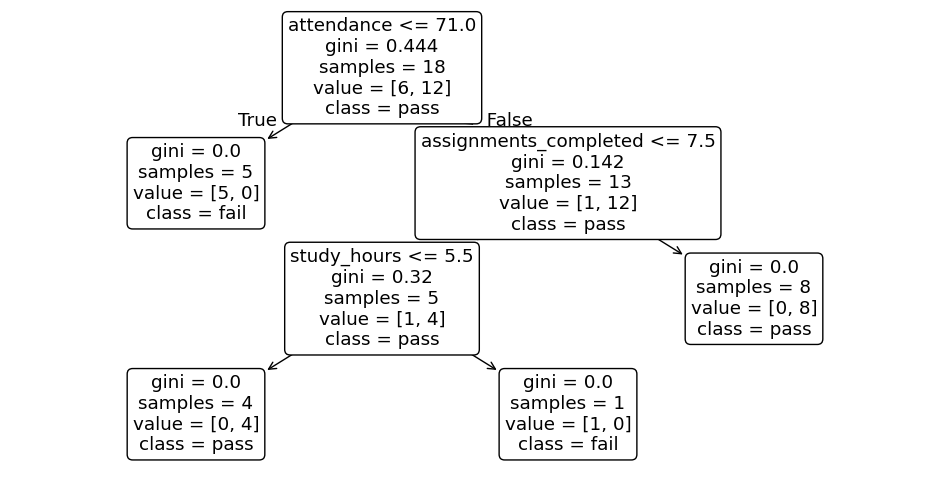

In [22]:
plt.figure(figsize=(12, 6))
plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=["fail", "pass"],
    filled=False,
    rounded=True,
    max_depth=3
)
plt.show()


The purpose is not to declare one algorithm universally better.

Different algorithms can learn different decision structures from the same data.

# Part H: Evaluation

## 17. Why accuracy alone can fail

Imagine a class where most students do **not** need extra support.

Suppose 20 students are being checked:
- 18 do not need support
- 2 do need support

A model that always predicts "does not need support" gets 90% accuracy.

That sounds good, but it catches **none** of the students who actually need support.

This shows why we also need metrics such as recall and precision.


In [23]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

y_imbalanced = np.array([0] * 18 + [1] * 2)
pred_all_normal = np.zeros_like(y_imbalanced)

print("Accuracy:", accuracy_score(y_imbalanced, pred_all_normal))
print("Recall for students needing support:",
      recall_score(y_imbalanced, pred_all_normal, zero_division=0))


Accuracy: 0.9
Recall for students needing support: 0.0


The 99 percent accuracy sounds excellent.

Operationally, the model is useless if its purpose is to detect faults.

This is why evaluation must examine the kinds of mistakes the model makes.

## 18. The confusion matrix

For a binary classification problem:

- **True Positive (TP):** predicted pass, actually pass
- **False Positive (FP):** predicted pass, actually fail
- **False Negative (FN):** predicted fail, actually pass
- **True Negative (TN):** predicted fail, actually fail

For student support or pass/fail prediction, a false negative means the model missed a student who actually belongs to the positive class.


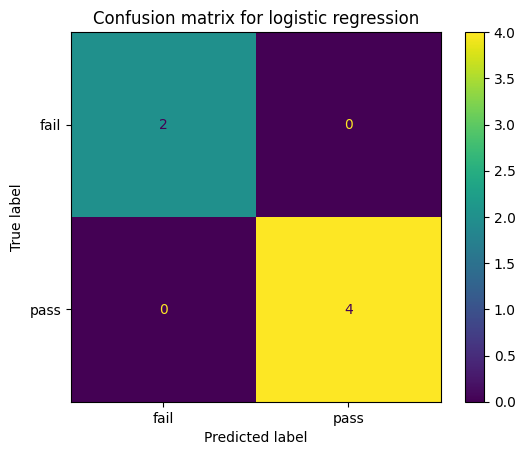

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["fail", "pass"]
)
plt.title("Confusion matrix for logistic regression")
plt.show()


In [25]:
cm = confusion_matrix(y_test, logistic_predictions)

tn, fp, fn, tp = cm.ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

True negatives: 2
False positives: 0
False negatives: 0
True positives: 4


## 19. Accuracy, precision, recall, and F1

### Accuracy

\[
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
\]

Question:

> What fraction of all predictions were correct?

### Precision

\[
\text{Precision} = \frac{TP}{TP + FP}
\]

Question:

> Of the cases predicted as positive, how many were truly positive?

### Recall

\[
\text{Recall} = \frac{TP}{TP + FN}
\]

Question:

> Of the actual positives, how many did we catch?

### F1 score

\[
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
\]

F1 summarizes the balance between precision and recall.

In [26]:
metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, logistic_predictions),
    "Precision": precision_score(y_test, logistic_predictions, zero_division=0),
    "Recall": recall_score(y_test, logistic_predictions, zero_division=0),
    "F1": f1_score(y_test, logistic_predictions, zero_division=0)
})

metrics.round(3)

Accuracy     1.0
Precision    1.0
Recall       1.0
F1           1.0
dtype: float64

## 20. Manual metric calculation

Use this simple confusion matrix:

- TP = 8
- FP = 2
- FN = 1
- TN = 9

Before running the next cell, calculate accuracy, precision, recall, and F1 yourself.


In [27]:
tp = 8
fp = 2
fn = 1
tn = 9

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1:        {f1:.2%}")


Accuracy:  85.00%
Precision: 80.00%
Recall:    88.89%
F1:        84.21%


### Interpretation

- **Recall** tells us how many of the actual positive cases the model found.
- **Precision** tells us how often a positive prediction was correct.
- **F1** combines precision and recall into one score.

Which metric matters most depends on the real-world goal and the cost of different mistakes.


# Part I: Regression metrics

## 21. A small regression problem

We will predict a student's **exam score** from their **study hours**.

The target is a continuous number, so this is a regression problem.


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regression_df = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "exam_score": [35, 42, 48, 55, 61, 68, 72, 80, 86, 92]
})

X_reg = regression_df[["study_hours"]]
y_reg = regression_df["exam_score"]

Xreg_train, Xreg_test, yreg_train, yreg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

reg_model = LinearRegression()
reg_model.fit(Xreg_train, yreg_train)

reg_predictions = reg_model.predict(Xreg_test)

mae = mean_absolute_error(yreg_test, reg_predictions)
mse = mean_squared_error(yreg_test, reg_predictions)
rmse = mse ** 0.5
r2 = r2_score(yreg_test, reg_predictions)

print(f"MAE:  {mae:.2f} marks")
print(f"MSE:  {mse:.2f} squared marks")
print(f"RMSE: {rmse:.2f} marks")
print(f"R^2:  {r2:.3f}")


MAE:  0.55 marks
MSE:  0.46 squared marks
RMSE: 0.68 marks
R^2:  0.999


### Interpreting common regression metrics

**MAE**

Average absolute size of the prediction errors in the original unit.

**MSE**

Squares the errors before averaging. Large mistakes receive a stronger penalty.

**RMSE**

Square root of MSE. It is expressed in the original unit and still gives extra influence to large errors.

**R squared**

Compares the model with a simple mean-based reference.

For example, if MAE is 3 marks, the predictions are off by about 3 marks on average.


## 22. Residuals

A residual is:

\[
\text{Residual} = \text{Actual} - \text{Predicted}
\]

A positive residual means the actual value was higher than the prediction.

A negative residual means the actual value was lower than the prediction.

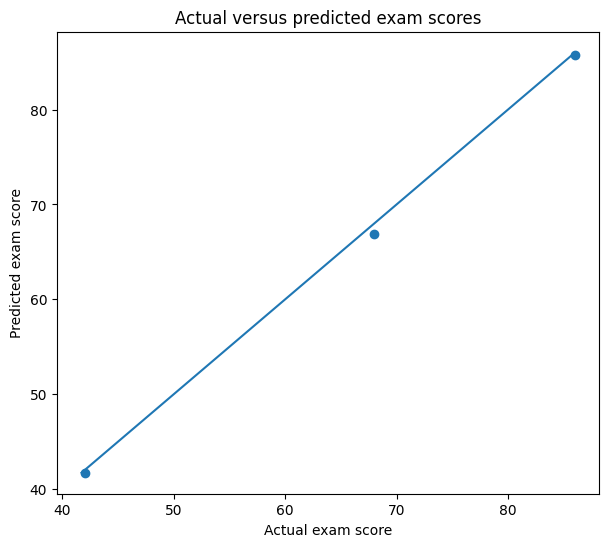

In [29]:
residuals = yreg_test.to_numpy() - reg_predictions

plt.figure(figsize=(7, 6))
plt.scatter(yreg_test, reg_predictions)
minimum = min(yreg_test.min(), reg_predictions.min())
maximum = max(yreg_test.max(), reg_predictions.max())
plt.plot([minimum, maximum], [minimum, maximum])
plt.xlabel("Actual exam score")
plt.ylabel("Predicted exam score")
plt.title("Actual versus predicted exam scores")
plt.show()


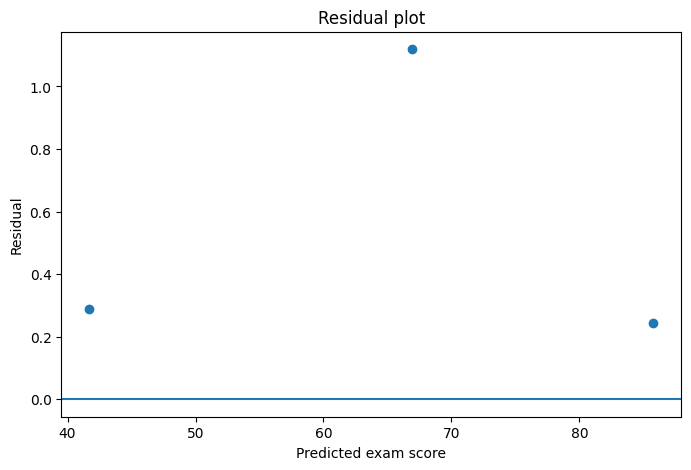

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(reg_predictions, residuals)
plt.axhline(0)
plt.xlabel("Predicted exam score")
plt.ylabel("Residual")
plt.title("Residual plot")
plt.show()


Look for patterns in the residual plot.

A good model does not require residuals to be exactly zero, but systematic patterns can indicate that the model is missing useful structure.

# Part J: Generalisation, underfitting, and overfitting

## 23. Build a noisy nonlinear dataset

We will use a simple student example:

> As study hours change, exam scores do not always follow a perfectly straight line.

We add a little random noise so the data looks more realistic.

Then we compare decision trees of different complexity.


In [31]:
x_curve = np.linspace(1, 10, 25)

y_curve = (
    70
    + 15 * np.sin(x_curve / 1.5)
    + rng.normal(0, 4, len(x_curve))
)

curve_df = pd.DataFrame({
    "study_hours": x_curve,
    "exam_score": y_curve
})

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    curve_df[["study_hours"]],
    curve_df["exam_score"],
    test_size=0.30,
    random_state=42
)

x_grid = np.linspace(1, 10, 500).reshape(-1, 1)


In [ ]:
x_curve

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


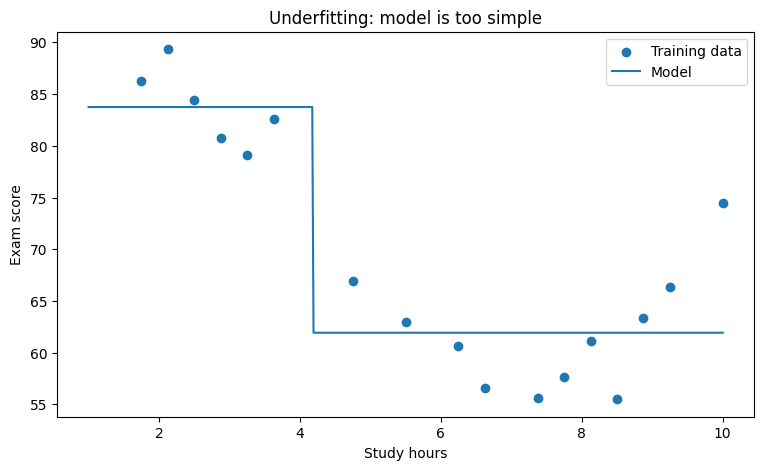

Training R^2: 0.819
Test R^2: 0.267


In [ ]:
from sklearn.tree import DecisionTreeRegressor

underfit_model = DecisionTreeRegressor(max_depth=1, random_state=42)
underfit_model.fit(Xc_train, yc_train)

plt.figure(figsize=(9, 5))
plt.scatter(Xc_train["study_hours"], yc_train, label="Training data")
plt.plot(x_grid[:, 0], underfit_model.predict(x_grid), label="Model")
plt.xlabel("Study hours")
plt.ylabel("Exam score")
plt.title("Underfitting: model is too simple")
plt.legend()
plt.show()

print("Training R^2:", round(underfit_model.score(Xc_train, yc_train), 3))
print("Test R^2:", round(underfit_model.score(Xc_test, yc_test), 3))

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


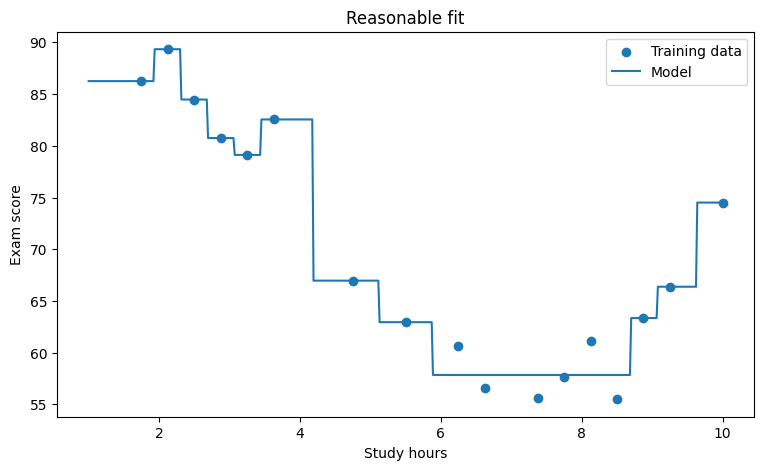

Training R^2: 0.986
Test R^2: 0.531


In [33]:
reasonable_model = DecisionTreeRegressor(max_depth=4, random_state=42)
reasonable_model.fit(Xc_train, yc_train)

plt.figure(figsize=(9, 5))
plt.scatter(Xc_train["study_hours"], yc_train, label="Training data")
plt.plot(x_grid[:, 0], reasonable_model.predict(x_grid), label="Model")
plt.xlabel("Study hours")
plt.ylabel("Exam score")
plt.title("Reasonable fit")
plt.legend()
plt.show()

print("Training R^2:", round(reasonable_model.score(Xc_train, yc_train), 3))
print("Test R^2:", round(reasonable_model.score(Xc_test, yc_test), 3))

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


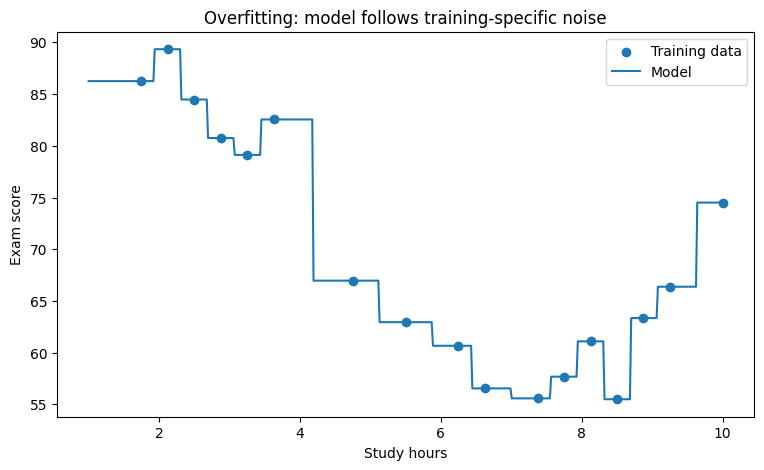

Training R^2: 1.0
Test R^2: 0.528


In [34]:
overfit_model = DecisionTreeRegressor(max_depth=None, random_state=42)
overfit_model.fit(Xc_train, yc_train)

plt.figure(figsize=(9, 5))
plt.scatter(Xc_train["study_hours"], yc_train, label="Training data")
plt.plot(x_grid[:, 0], overfit_model.predict(x_grid), label="Model")
plt.xlabel("Study hours")
plt.ylabel("Exam score")
plt.title("Overfitting: model follows training-specific noise")
plt.legend()
plt.show()

print("Training R^2:", round(overfit_model.score(Xc_train, yc_train), 3))
print("Test R^2:", round(overfit_model.score(Xc_test, yc_test), 3))

### Interpretation

**Underfitting**

- weak training performance
- weak test performance
- model is too simple to capture useful structure

**Reasonable fit**

- good training performance
- similar unseen performance
- useful pattern transfers

**Overfitting**

- extremely strong training performance
- weaker unseen performance
- model follows training-specific noise

More complex does not automatically mean better.

# Part K: Data leakage

## 24. The cheating machine

Suppose a school wants to predict **by the end of Week 5** which students need extra support.

At prediction time, we can use:
- attendance in Week 5
- quiz average
- study hours
- missed assignments

But the **final exam grade is not available yet**.

If we give the model the final grade, we are allowing it to see information from the future.

That is **data leakage**.


In [35]:
n_students = 40

attendance_week5 = rng.integers(50, 101, n_students)
quiz_average = rng.integers(40, 91, n_students)
study_hours = rng.integers(1, 11, n_students)
missed_assignments = rng.integers(0, 5, n_students)

risk_score = (
    (attendance_week5 < 65).astype(int)
    + (quiz_average < 55).astype(int)
    + (study_hours < 4).astype(int)
    + (missed_assignments >= 3).astype(int)
)

needs_support = (risk_score >= 2).astype(int)

final_grade = (
    0.5 * attendance_week5
    + 0.4 * quiz_average
    + 2 * study_hours
    - 4 * missed_assignments
    - 20 * needs_support
    + rng.normal(0, 3, n_students)
).clip(0, 100)

student_support_df = pd.DataFrame({
    "attendance_week5": attendance_week5,
    "quiz_average": quiz_average,
    "study_hours": study_hours,
    "missed_assignments": missed_assignments,
    "final_grade": final_grade,
    "needs_support": needs_support
})

student_support_df.head()


,attendance_week5,quiz_average,study_hours,missed_assignments,final_grade,needs_support
0,62,65,4,1,63.514380,0
1,55,79,10,3,53.090193,1
2,72,90,4,0,88.741587,0
3,84,73,10,2,84.443228,0
4,83,60,5,0,72.531386,0


In [36]:
legitimate_features = [
    "attendance_week5",
    "quiz_average",
    "study_hours",
    "missed_assignments"
]

leaky_features = legitimate_features + ["final_grade"]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    student_support_df,
    student_support_df["needs_support"],
    test_size=0.25,
    random_state=42,
    stratify=student_support_df["needs_support"]
)

safe_model = LogisticRegression(max_iter=1000)
safe_model.fit(Xs_train[legitimate_features], ys_train)
safe_pred = safe_model.predict(Xs_test[legitimate_features])

leaky_model = LogisticRegression(max_iter=1000)
leaky_model.fit(Xs_train[leaky_features], ys_train)
leaky_pred = leaky_model.predict(Xs_test[leaky_features])

print("Model using only Week 5 information:")
print("Accuracy:", round(accuracy_score(ys_test, safe_pred), 3))

print("\nModel using final grade (LEAKAGE):")
print("Accuracy:", round(accuracy_score(ys_test, leaky_pred), 3))


Model using only Week 5 information:
Accuracy: 1.0

Model using final grade (LEAKAGE):
Accuracy: 1.0


The second model may look better, but it is not a fair Week 5 prediction system.

### The most important leakage question

**Could I know this value at the exact moment the prediction must be made?**

If the honest answer is no, the feature should not be used for that prediction task.

## 25. Common leakage channels

### Target leakage

Information very closely tied to the answer is used as a feature.

Example:

Predict whether a student needs support using a variable that was created from the same final outcome.

### Future leakage

Information recorded after the prediction time is used.

Example:

Predict Week 5 support need using the final exam mark.

### Duplicate or group leakage

The same student appears in both training and test data in a way that makes the test artificially easy.

### Preprocessing leakage

Scaling, imputation, or other transformations learn from the complete dataset before the split.


## 26. Preprocessing leakage: wrong and correct patterns

### Wrong pattern

```python
scaler.fit(X)
X_scaled = scaler.transform(X)
train_test_split(X_scaled, y)
```

The scaler learned information from all observations, including the future test set.

### Better pattern

```python
X_train, X_test, y_train, y_test = train_test_split(X, y)
scaler.fit(X_train)
```

### Safer scikit-learn pattern

Use a `Pipeline`.

The preprocessing step is then fitted using training data during model fitting.

In [37]:
safe_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

safe_pipeline.fit(X_train, y_train)
pipeline_predictions = safe_pipeline.predict(X_test)

print("Pipeline test accuracy:", round(accuracy_score(y_test, pipeline_predictions), 3))

Pipeline test accuracy: 1.0


# Part L: Validation and cross-validation

## 27. Train, validation, and test sets

During model development, we often need three roles:

- **Training set:** fit model parameters.
- **Validation set:** compare models or hyperparameters during development.
- **Test set:** final held-out evidence after decisions are made.

If you repeatedly check the test set and change the model based on its score, the test set has effectively become another validation set.

In [38]:
X_train_full, X_final_test, y_train_full, y_final_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train2, X_valid, y_train2, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

print("Training rows:", len(X_train2))
print("Validation rows:", len(X_valid))
print("Final test rows:", len(X_final_test))

Training rows: 14
Validation rows: 5
Final test rows: 5


## 28. Cross-validation

A single validation split can be lucky or unlucky.

Cross-validation repeatedly changes which portion acts as the validation fold and averages the scores.

In [39]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score:.3f}")

print("\nMean F1:", round(scores.mean(), 3))
print("Standard deviation:", round(scores.std(), 3))

Fold 1: 0.800
Fold 2: 1.000
Fold 3: 1.000
Fold 4: 0.889
Fold 5: 1.000

Mean F1: 0.938
Standard deviation: 0.081


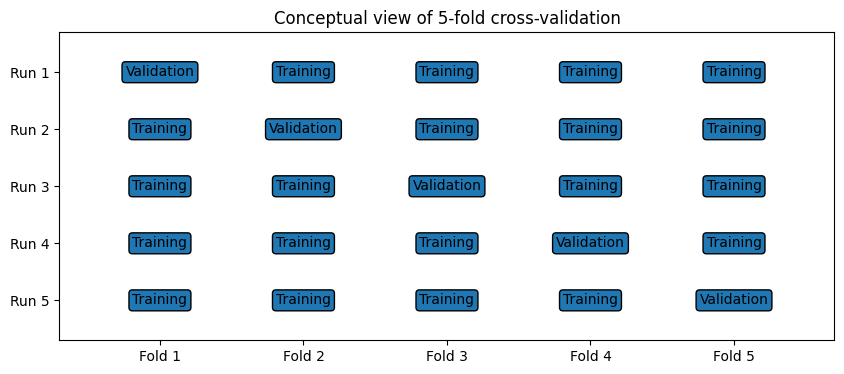

In [40]:
folds = 5

fig, ax = plt.subplots(figsize=(10, 4))
for row in range(folds):
    for col in range(folds):
        label = "Validation" if row == col else "Training"
        ax.text(
            col,
            folds - row,
            label,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.25")
        )

ax.set_xlim(-0.7, folds - 0.3)
ax.set_ylim(0.3, folds + 0.7)
ax.set_xticks(range(folds))
ax.set_xticklabels([f"Fold {i}" for i in range(1, folds + 1)])
ax.set_yticks(range(1, folds + 1))
ax.set_yticklabels([f"Run {i}" for i in range(folds, 0, -1)])
ax.set_title("Conceptual view of 5-fold cross-validation")
plt.show()

# Part M: Reproducibility and error analysis

## 29. Reproducibility

A good machine learning report should describe enough detail that another person can rebuild the result.

Record:

- dataset or dataset version
- target definition
- feature list
- split logic
- random seed
- preprocessing
- algorithm
- hyperparameters
- evaluation metrics

Keep transformations in code where possible.

`random_state` makes a random process repeatable. It does not magically improve accuracy.

## 30. Do not stop at the score

Error analysis asks what the model got wrong.

Useful questions include:

- Which examples were wrong?
- Are false negatives concentrated in a particular region or subgroup?
- Are errors linked to missing values?
- Are labels questionable?
- Are mistakes near a decision boundary?
- What should a human inspect next?

In [41]:
error_table = X_test.copy()
error_table["actual"] = y_test.to_numpy()
error_table["predicted"] = logistic_predictions
error_table["correct"] = error_table["actual"] == error_table["predicted"]

mistakes = error_table[~error_table["correct"]].copy()

print("Number of test mistakes:", len(mistakes))
display(mistakes.head(10))

Number of test mistakes: 0


,study_hours,attendance,assignments_completed,actual,predicted,correct


In [42]:
false_negatives = error_table[
    (error_table["actual"] == 1) &
    (error_table["predicted"] == 0)
].copy()

print("False negatives, meaning missed faults:", len(false_negatives))
display(false_negatives.head(10))

False negatives, meaning missed faults: 0


,study_hours,attendance,assignments_completed,actual,predicted,correct


Look at the students the model got wrong.

Ask questions such as:
- Did some students study very little?
- Did some students have low attendance?
- Are there students whose behaviour is different from the rest?

Error analysis helps us understand **where** the model fails, not just how high its score is.


# Part N: A complete mini machine learning workflow

## 31. One compact reference pipeline

The code below brings the major steps together:

1. define features and target
2. split
3. create preprocessing and model pipeline
4. build a baseline
5. train
6. predict
7. evaluate
8. inspect errors

In [43]:
# 1. Features and target
X_full = student_df.drop(columns="passed")
y_full = student_df["passed"]

# 2. Split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.25,
    random_state=42,
    stratify=y_full
)

# 3. Pipeline
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# 4. Baseline
final_baseline = DummyClassifier(strategy="most_frequent")
final_baseline.fit(X_train_full, y_train_full)
baseline_pred = final_baseline.predict(X_test_full)

# 5. Train
final_model.fit(X_train_full, y_train_full)

# 6. Predict
final_pred = final_model.predict(X_test_full)

# 7. Evaluate
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Baseline": [
        accuracy_score(y_test_full, baseline_pred),
        precision_score(y_test_full, baseline_pred, zero_division=0),
        recall_score(y_test_full, baseline_pred, zero_division=0),
        f1_score(y_test_full, baseline_pred, zero_division=0)
    ],
    "Logistic Regression": [
        accuracy_score(y_test_full, final_pred),
        precision_score(y_test_full, final_pred, zero_division=0),
        recall_score(y_test_full, final_pred, zero_division=0),
        f1_score(y_test_full, final_pred, zero_division=0)
    ]
})

display(results.round(3))

# 8. Inspect errors
inspection = X_test_full.copy()
inspection["actual"] = y_test_full.to_numpy()
inspection["predicted"] = final_pred
inspection["error"] = inspection["actual"] != inspection["predicted"]

print("Number of errors:", inspection["error"].sum())
display(inspection[inspection["error"]].head())


,Metric,Baseline,Logistic Regression
0,Accuracy,0.667,1.0
1,Precision,0.667,1.0
2,Recall,1.000,1.0
3,F1,0.800,1.0


Number of errors: 0


,study_hours,attendance,assignments_completed,actual,predicted,error


# Part O: Final TODO activities

These are the parts you should complete yourself.

Do not aim only for a high score. Explain what the result means.

## TODO 1: Change the model

Replace logistic regression with `KNeighborsClassifier`.

### Your task

1. Import `KNeighborsClassifier`.
2. Build a pipeline with `StandardScaler` and KNN.
3. Fit it using `X_train` and `y_train`.
4. Make predictions on `X_test`.
5. Calculate accuracy, precision, recall, and F1.
6. Compare KNN with the baseline and logistic regression.


In [44]:
# TODO 1

from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# TODO: fit the model using X_train and y_train

# TODO: make predictions using X_test

# TODO: calculate accuracy, precision, recall, and F1

# TODO: compare your results with the baseline and logistic regression


### TODO 1 reflection

Write your interpretation below.

**My interpretation:**

...


## TODO 2: Change the classification threshold

Many binary classifiers produce probabilities.

Instead of automatically using 0.50 as the cutoff, try different thresholds.

For example:
- 0.30
- 0.50
- 0.70

Think about what happens to precision and recall when the threshold changes.


In [45]:
# TODO 2

probabilities = logistic_model.predict_proba(X_test)[:, 1]

thresholds = [0.30, 0.50, 0.70]

# TODO:
# Loop through the thresholds.
# Convert probabilities to 0 or 1 predictions.
# Calculate precision and recall for each threshold.
# Print the results.

for threshold in thresholds:
    threshold_predictions = (probabilities >= threshold).astype(int)

    precision = precision_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_predictions,
        zero_division=0
    )

    print(
        f"Threshold {threshold:.2f} -> "
        f"Precision: {precision:.3f}, "
        f"Recall: {recall:.3f}"
    )


Threshold 0.30 -> Precision: 0.800, Recall: 1.000
Threshold 0.50 -> Precision: 1.000, Recall: 1.000
Threshold 0.70 -> Precision: 1.000, Recall: 1.000


### TODO 2 reflection

Which threshold would you choose for a safety-critical student-support detector?

Explain why.

...

## TODO 3: Find the leakage

A school wants to predict **by the end of Week 5** which students need extra support.

You are given:
- Week 5 attendance
- quiz average
- study hours
- missed assignments
- final exam grade
- whether the student eventually needed support

### Your task

Identify:

1. **Prediction unit:** What does one row represent?
2. **Target:** What are we predicting?
3. **Prediction time:** When must the prediction be made?
4. **Legitimate features:** Which columns are available at prediction time?
5. **Leaky feature:** Which column contains future information?


### TODO 3 answer

**Prediction unit:**

...

**Target:**

...

**Prediction time:**

...

**Legitimate features:**

...

**Leakage variables:**

...

**Split strategy:**

...

**Evaluation metrics and justification:**

...

## TODO 4: Would you deploy it?

Consider two student-support models.

| Model | Accuracy | Recall for students needing support |
|---|---:|---:|
| Model A | 95% | 20% |
| Model B | 90% | 85% |

Ask yourself:

> Which model would you prefer if the main goal is to identify students who need support?

There is no automatic answer. You need to connect the metric to the real-world goal.


### TODO 4 answer

**My decision:**

...

**Reasoning:**

...

# Final recap

A trustworthy machine learning workflow is more than:

```python
model.fit(...)
```

A better summary is:

**Frame -> Data -> Audit -> Split -> Prepare -> Baseline -> Train -> Evaluate -> Inspect -> Decide**

Before trusting a claim such as:

> "My AI model achieved 98% accuracy."

ask questions such as:

1. What data was used?
2. What was the baseline?
3. How were training and test data separated?
4. Could there be leakage?
5. Are the classes balanced?
6. Which errors occurred?
7. What are the consequences of false positives and false negatives?
8. Does the model generalise to the intended deployment environment?

The central goal is not to produce a large score.

The goal is to build trustworthy evidence that a model performs usefully on relevant cases it has not seen before.